# Set Up
<ol>
    <li> Implement <u>at least</u> two NMF algorithms </li> <!--- Look into alternatives for themethod. --->
    <ul>
        <li>Specify the loss function (MINIMIZATION)</li>
        <li>Specify the optimization method</li>
    </ul>
    <li>Analyze robustness</li>
    <ul>
        <li>Minor preprocessing</li>
        <li>Noise (requires demonstration)</li>
        <li>Clearly show relative robustnesses</li> <!--- will require research--->
    </ul>
</ol>

## Libraries
Scikit learn can be used for evaluation and NOT the implementation of the algorithm. Three following econstruction errors are suggested, of which only 1 is mandatory:
<ol>
    <li>Relative Reconstruction Errors(RRE)$$ RRE = \frac{||\hat V - WH||_F}{||\hat V||_F}$$
    </li>
    <li> Average Accuracy $$Acc(Y,Y_{pred}) = \frac{1}{n}\sum^n_{i=1}1\{Y_{pred}(i)==Y(i)\}$$  
    <\li>
    <li> Normalized Mutual Information (NMI)$$ NMI(Y,Y_{pred}) = \frac{2*I(Y,Y_{pred})}{H(Y)+H(Y_{pred})}$$
    <\li>

In [2]:
!ls -l data

total 8
drwxrwxrwx 40 taleni taleni 4096 Aug 25 16:59 CroppedYaleB
drwx------ 42 taleni taleni 4096 Aug 24 15:37 ORL


In [3]:
# Libraries
import os
import numpy as np
from PIL import Image
import matplotlib.pyplot as plt

In [4]:
def load_data_AR(root='data/CroppedAR', reduce=3):
    """ 
    Load AR dataset to numpy array.
    
    Args:
        root: path to AR dataset.
        reduce: scale factor for zooming out images.
        
    """ 
    images, labels = [], []
    
    for fname in os.listdir(root):
        
        if not fname.endswith('.bmp'):
            continue
        
        # get label.
        label = int(fname[2:5])
        if fname[0] == 'W': # start from 50
            label += 50
        
        # load image.
        img = Image.open(os.path.join(root, fname))
        img = img.convert('L') # grey
        
        # reduce computation complexity.
        img = img.resize([s//reduce for s in img.size])
   
        # TODO: preprocessing.
        
        # convert image to numpy array.
        img = np.asarray(img).reshape((-1,1))
        
        # collect data and label.
        images.append(img)
        labels.append(label)
        
    # concate all images and labels.
    images = np.concatenate(images, axis=1)
    labels = np.array(labels)
    
    return images, labels

In [101]:
def load_data(root='data/CroppedYaleB', reduce=4):
    """ 
    Load ORL (or Extended YaleB) dataset to numpy array.
    
    Args:
        root: path to dataset.
        reduce: scale factor for zooming out images.
        
    """ 
    images, labels = [], []

    for i, person in enumerate(sorted(os.listdir(root))):
        
        if not os.path.isdir(os.path.join(root, person)):
            continue
        
        for fname in os.listdir(os.path.join(root, person)):    
            
            # Remove background images in Extended YaleB dataset.
            if fname.endswith('Ambient.pgm'):
                continue
            
            if not fname.endswith('.pgm'):
                continue
                
            # load image.
            img = Image.open(os.path.join(root, person, fname))
            img = img.convert('L') # grey image.

            # reduce computation complexity.
            img = img.resize([s//reduce for s in img.size])
            shape = img.size

            # TODO: preprocessing.

            # convert image to numpy array.
            img = np.asarray(img).reshape((-1,1))
            
            
            # collect data and label.
            images.append(img)
            labels.append(i)
            
    
    # concate all images and labels.
    images = np.concatenate(images, axis=1)
    labels = np.array(labels)

    return images, labels, shape

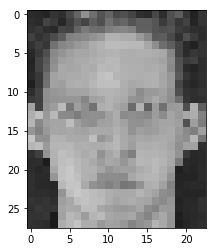

(28, 23)


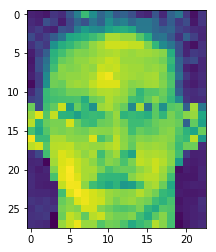

In [6]:
from PIL import Image
reduce = 4
img = Image.open('data/ORL/s1/1.pgm')
img = img.resize([s//reduce for s in img.size])
plt.imshow(img)
plt.show()
img = np.asarray(img)
print(img.shape)
img = img.reshape((-1,1))
img = img.reshape((28,23))
#plt.imshow(img.reshape(42,48))
plt.imshow(img) 

# STEPS
1. Preprocessing
2. NMF Implementations
3. Robustness Evaluations

In [102]:
# Loading data
#X,Y,shape = load_data(root='data/CroppedYaleB', reduce=4)
X,Y,shape = load_data(root='data/ORL', reduce=2)
print(shape)
# size = (48,42)|
## X,Y = load_data(root='data/ORL', reduce=2)
# size = (28,23)

(46, 56)


In [8]:
X.shape

(2016, 2414)

In [9]:
def calc_cost(X,P,Q):
    c = 1/n*np.sum(s)
    return c

In [10]:
# Image Processing
def initialize(X,rs = 1,K=2):
    # initialize 
    N,M = X.shape
    K = 2
    rng = np.random.RandomState(rs)
    P = rng.rand(N,K)
    Q = rng.rand(M,K)
    return P,Q

In [11]:
# L2 Multiplicative Updater
def L2mu(R, P, Q, steps):
    Q = Q.T
    for step in range(steps):
        Pu = P*(R.dot(Q.T))/(P.dot(Q).dot(Q.T))
        Qu = Q*(Pu.T.dot(R)/(Pu.T.dot(Pu).dot(Q)))
        e_P = np.sqrt(np.sum((Pu-P)**2, axis=(0,1)))/P.size
        e_Q = np.sqrt(np.sum((Qu-Q)**2, axis=(1,0)))/Q.size
        if e_P<0.001 and e_Q<0.001:
            #print("step is:",step)
            break
        P = Pu
        Q = Qu
    return P, Q.T    

In [12]:
def calc_d(X,P,Q):
    d = []
    for i in range(Q.shape[0]):
        tmp = 1/np.linalg.norm(X[:,i] - P.dot(Q[i,:]))
        d.append(tmp)
    d = np.asanyarray(d)
    return np.diag(d)

def L21mu(R,P,Q,steps):
    Q = Q.T
    D = calc_d(R,P,Q.T)
    for step in range(steps):
        Pu = P*(R.dot(D.dot(Q.T)))/(P.dot(Q.dot(D.dot(Q.T))))
        Qu = Q*(Pu.T.dot(R.dot(D)))/(Pu.T.dot(Pu.dot(Q.dot(D))))
        e_P = np.sqrt(np.sum((Pu-P)**2, axis=(0,1)))/P.size
        e_Q = np.sqrt(np.sum((Qu-Q)**2, axis=(1,0)))/Q.size
        if e_P<0.001 and e_Q<0.001:
            #print("step is:",step)
            break
        P = Pu
        Q = Qu
    return P, Q.T  

In [13]:
def calc_w(R,P,Q,eps = 0.001):
    w = ((R - P.dot(Q))**2 + eps**2)**0.5
    return w

def L1mu(R,P,Q,steps):
    Q = Q.T
    W = calc_w(R,P,Q)
    for step in range(steps):
        Pu = P*((R*W).dot(Q.T))/(((P.dot(Q))*W).dot(Q.T))
        Qu = Q*(Pu.T.dot((R*W)))/(Pu.T.dot(((Pu.dot(Q))*W)))
        e_P = np.sqrt(np.sum((Pu-P)**2, axis=(0,1)))/P.size
        e_Q = np.sqrt(np.sum((Qu-Q)**2, axis=(1,0)))/Q.size
        if e_P<0.001 and e_Q<0.001:
            #print("step is:",step)
            break
        P = Pu
        Q = Qu
    return P, Q.T  

In [14]:
def plot_p(p_estimate, model, n, RRE, K=2, shape=(48,42)):
    plt.figure(figsize=(6, 3))
    plt.suptitle("learned basises from "+ model +" with "+ n +" NMF", size=16)
    print('The RRE for %s is %f' % (model, RRE))
    for i in range(K):
        plt.subplot(1, K, i+1)
        plt.imshow(p_estimate[:,i].reshape(shape), cmap=plt.cm.gray)
        plt.xticks(())
        plt.yticks(())
    plt.show()
    

## Measuring the Evaluation Metrics
<ul><li> RRE </li>
    <li> Acc </li>
    <li> NMI </li>

In [15]:
# RRE
def RRE(V_hat, metrics,n, steps=100):
    d ={}
    P,Q = initialize(X)
    possible = [L21mu, L1mu,L2mu]
    for model in metrics:
        if model in possible:
            W, H = possible(X,P,Q,steps)
            RRE = np.linalg.norm(V_hat - W.dot(H.T)) / np.linalg.norm(V_hat)
            plot_p(W, 'L2mu', RRE2)
            d['L2mu'] = [W,H,RRE2]

    return d

# Noise

In [16]:
def add_noise(x, dist,scale):
    if dist =="gaus":
        noise = np.random.randn(x.shape[0],x.shape[1])*scale
        noisy_x = noise + x
    if dist =="laplace":
        noise = np.random.laplace(size=(x.shape[0],x.shape[1]))*scale
        noisy_x = noise + x
    if dist == "cauchy":
        noise = np.random.standard_cauchy((x.shape[0],x.shape[1]))
        noisy_x = noise + x       
    return noisy_x, noise

In [68]:
import random

def add_block(X,shape,r):
    
    r = min(r,min(shape))
    
    m = X.shape[1]
    n = X.shape[0]
    X = X.reshape(*shape, m)
    
    X_final = np.zeros(X.shape)
    one_final = np.ones(X.shape)
    for img in range(m):
        random.seed(img)
        i,j = random.randint(0,shape[0]-r), random.randint(0,shape[1]-r)

        block = np.zeros((r,r))
        X_tmp = np.matrix.copy(X[:,:,img])
        X_tmp[i:i+r,j:j+r] = block
        one_tmp = np.ones(shape)
        one_tmp[i:i+r, j:j+r]= block
        
        X_final[:,:,img] = X_tmp
        one_final[:,:,img] = one_tmp
    
    X_final = X_final.reshape(n,m)
    one_final = one_final.reshape(n,m)
    return X_final, one_final

#aX_final, aone_final = add_block(X,(48,42), r=20)

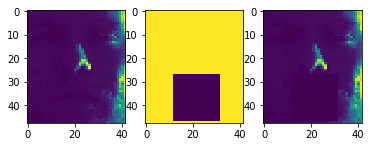

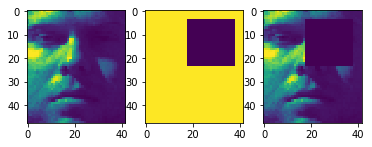

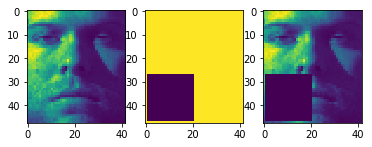

In [18]:
for i in range(3):    
    plt.subplot('131')
    plt.imshow(X[:,i].reshape(48,42))
    plt.subplot('132')
    plt.imshow(aone_final[:,i].reshape(48,42))
    plt.subplot('133')
    plt.imshow(aX_final[:,i].reshape(48,42))
    plt.show()

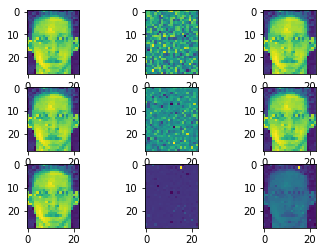

In [19]:
img = Image.open('data/ORL/s1/1.pgm')
img = img.resize([s//reduce for s in img.size])
img = np.asarray(img)
scale = 1
#for i in range(3):
#plt.subplot("".join(['13',str(i)]))
plt.subplot('331')
plt.imshow(img)

plt.subplot('332')
noisy_img, noise = add_noise(img, 'gaus',scale)
plt.imshow(noise)

plt.subplot('333')
plt.imshow(noisy_img) 

plt.subplot('334')
plt.imshow(img)

plt.subplot('335')
noisy_img, noise = add_noise(img, 'laplace',scale)
plt.imshow(noise)

plt.subplot('336')
plt.imshow(noisy_img) 

plt.subplot('337')
plt.imshow(img)

plt.subplot('338')
noisy_img, noise = add_noise(img, 'cauchy',scale)
plt.imshow(noise)

plt.subplot('339')
plt.imshow(noisy_img) 

plt.show()

# Evaluation

In [20]:
from collections import Counter
from sklearn.cluster import KMeans
from sklearn.metrics import accuracy_score
from sklearn.metrics import normalized_mutual_info_score

def assign_cluster_label(H, Y):
    kmeans = KMeans(n_clusters=len(set(Y))).fit(H)
    Y_pred = np.zeros(Y.shape)
    for i in set(kmeans.labels_):
        ind = kmeans.labels_ == i
        Y_pred[ind] = Counter(Y[ind]).most_common(1)[0][0] # assign label.
    return Y_pred

# Putting it all together

Acc = 0.0829 
NMI = 0.0877
The RRE for L21mu is 0.380795


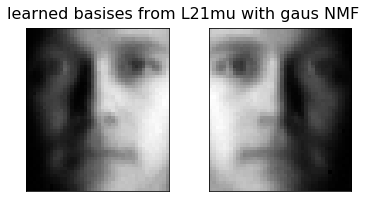

Acc = 0.0849 
NMI = 0.0860
The RRE for L21mu is 0.387651


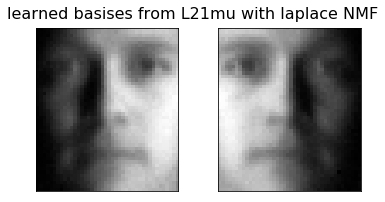

Acc = 0.0895 
NMI = 0.1121
The RRE for L1mu is 0.580687


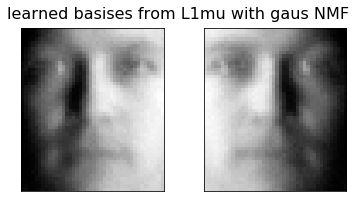

Acc = 0.0915 
NMI = 0.1047
The RRE for L1mu is 0.715645


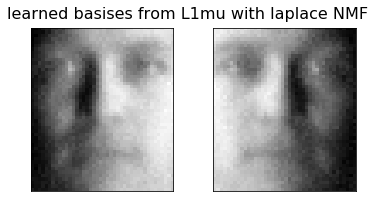

Acc = 0.0816 
NMI = 0.0844
The RRE for L2mu is 0.379443


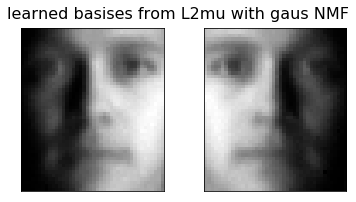

Acc = 0.0829 
NMI = 0.0901
The RRE for L2mu is 0.386183


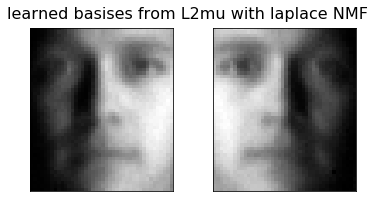

In [21]:
d ={}
P,Q = initialize(X)
steps = 100
V_hat = X
possible = [L21mu, L1mu,L2mu]
metrics = [L21mu,L1mu, L2mu]
noise_types = ['gaus', 'laplace']
for model in metrics:
    for n in noise_types:
        if model in possible:
            Vnoisy, noise = add_noise(X, n,40)
            Vnoisy = np.clip(Vnoisy,a_min=0,a_max=None)
            W, H = model(Vnoisy,P,Q,steps)
            RRE = np.linalg.norm(V_hat - W.dot(H.T)) / np.linalg.norm(V_hat)

            Y_pred = assign_cluster_label(H, Y)
            acc = accuracy_score(Y, Y_pred)
            nmi = normalized_mutual_info_score(Y, Y_pred)
            print('Acc = {:.4f} \nNMI = {:.4f}'.format(acc, nmi))

            plot_p(W, str(model).split()[1],n, RRE)
            
            key = str(model).split()[1]+'_'+n
            d[key]  = [W,H,n,RRE, acc, nmi]

In [99]:
d ={}
P,Q = initialize(X)
steps = 100
V_hat = X
possible = [L21mu, L1mu,L2mu]
metrics = [L21mu,L1mu, L2mu]
#noise_types = ['gaus', 'cauchy', 'laplace']
noise_types = ['gaus', 'gaus', 'gaus']
for i,model in enumerate(metrics):
    if model in possible:
        Vnoisy, noise = add_block(X,(48,42), 20)
        W, H = model(Vnoisy,P,Q,steps)
        Vnoisy = np.clip(Vnoisy,a_min=0,a_max=None)
        
        # Evaluations
        RRE = np.linalg.norm(V_hat - W.dot(H.T)) / np.linalg.norm(V_hat)
        Y_pred = assign_cluster_label(W.dot(H.T), Y)
        acc = accuracy_score(Y, Y_pred)
        nmi = normalized_mutual_info_score(Y, Y_pred)

        key = str(model).split()[1]+'_'+n
        d[key]  = [W,H,n,RRE, acc, nmi]
        


IndexError: boolean index did not match indexed array along dimension 0; dimension is 2414 but corresponding boolean dimension is 2016

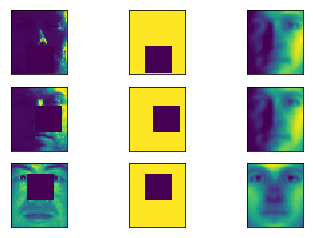

In [66]:
Vn = W.dot(H.T)
p = [Vnoisy, noise, Vn]
num_rows = 3

for row in range(num_rows):
    #for who in [10, 20 ,30]:
        for col, j in enumerate(p):
            r = row*40
            plt.subplot("".join(['33',str(num_rows*row+col+1)]))
            plt.imshow(j[:,r].reshape(48,42))
            plt.xticks(())
            plt.yticks(())
plt.show()

In [23]:
Y_pred = assign_cluster_label(H, Y)
acc = accuracy_score(Y, Y_pred)
nmi = normalized_mutual_info_score(Y, Y_pred)
print('Acc(NMI) = {:.4f} ({:.4f})'.format(acc, nmi))

Acc(NMI) = 0.0845 (0.0894)


In [ ]:
print(tuple(d['L21mu_laplace'][-3:]))
print('RRE = {}, NMI = {}, Acc = {}'.format(d['L21mu_laplace'][-3],d['L21mu_laplace'][-2],d['L21mu_laplace'][-1]))


In [58]:
q = (10, 20)
max(q)

20